In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

In [34]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [35]:
digit_a = 0
digit_b = 1

In [36]:
mask = (y == digit_a) | (y == digit_b)

X = X[mask]
y = y[mask]

print(X.shape)
print(y.shape)

(14780, 784)
(14780,)


In [37]:
y = np.where(y == digit_a, 0, 1)

print(np.unique(y))

[0 1]


In [38]:
scaler = MinMaxScaler()

X = scaler.fit_transform(X)

print(X.min())
print(X.max())

0.0
1.0


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(11824, 784)
(2956, 784)


In [40]:
pca = PCA(n_components=4)

X_train_pca = pca.fit_transform(X_train)

X_test_pca = pca.transform(X_test)

In [41]:
print("Explained variance ratio:")

print(pca.explained_variance_ratio_)

print()

print("Total explained variance:")

print(np.sum(pca.explained_variance_ratio_))

Explained variance ratio:
[0.32132101 0.09007806 0.07991434 0.05670596]

Total explained variance:
0.5480193700706227


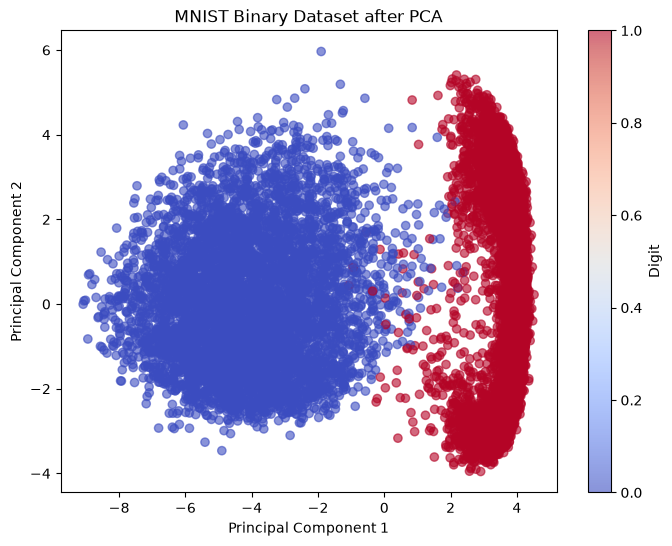

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap="coolwarm",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("MNIST Binary Dataset after PCA")

plt.colorbar(label="Digit")

plt.show()

In [43]:
os.makedirs("../data/binary", exist_ok=True)

In [44]:
np.save("../data/binary/X_train.npy", X_train_pca)

np.save("../data/binary/X_test.npy", X_test_pca)

np.save("../data/binary/y_train.npy", y_train)

np.save("../data/binary/y_test.npy", y_test)

In [45]:
X_train = np.load("../data/binary/X_train.npy")

y_train = np.load("../data/binary/y_train.npy")

print(X_train.shape)

print(y_train.shape)

(11824, 4)
(11824,)
